# Logistic Regression: Complete Study Notes

**Topics Covered:**
1. Sklearn Implementation of Logistic Regression
2. Accuracy Metric
3. Hyperparameter Tuning & Regularization
4. Log Odds / Logit
5. Impact of Outliers
6. Multiclass Classification

---

## 1. Sklearn Implementation of Logistic Regression

### 1.1 The Pipeline

```
Load Data → Select Features → Train/Val/Test Split → Scale Features → Fit Model → Evaluate
```

### 1.2 Feature Selection

**Why select only some features?**
- **Relevance**: Not all features predict the target (e.g., phone number doesn't predict churn)
- **Multicollinearity**: Correlated features cause instability
- **Overfitting**: Too many features → model memorizes noise
- **Simplicity**: Fewer features = easier interpretation

### 1.3 Train/Validation/Test Split

| Set | Purpose | Typical Size |
|-----|---------|-------------|
| Training | Learn patterns | 60% |
| Validation | Tune hyperparameters, check overfitting | 20% |
| Test | Final evaluation (only used once!) | 20% |

### 1.4 Feature Scaling with StandardScaler

**The Problem:** Features on different scales (e.g., minutes: 0-350, calls: 0-9) cause unfair learning.

**The Solution:** Standardization transforms each feature to mean=0, std=1:

\[ z = \frac{x - \mu}{\sigma} \]

**Critical Rule:** Fit scaler on training data ONLY, then transform all sets.

```python
scaler = StandardScaler()
scaler.fit(X_train)           # Learn from training ONLY

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)     # Apply same transformation
X_test = scaler.transform(X_test)
```

### 1.5 Model Coefficients

After fitting, the model learns weights for each feature:

| Feature | Coefficient | Interpretation |
|---------|-------------|----------------|
| CustServ Calls | 0.796 | Strongest predictor! |
| Day Mins | 0.684 | Second strongest |
| Eve Mins | 0.291 | Moderate |
| Night Mins | 0.136 | Weak |
| Account Length | 0.061 | Very weak |

**Positive coefficient** → Higher value = Higher probability of churn

---

## 2. Accuracy Metric

### Formula

\[ \text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total predictions}} \]

### Implementation (PyTorch)

```python
def accuracy(y_true, y_pred):
    y_true = torch.tensor(y_true.values) if hasattr(y_true, 'values') else torch.tensor(y_true)
    y_pred = torch.tensor(y_pred)
    return (y_true == y_pred).sum().item() / len(y_true)
```

### Interpreting Results

| Accuracy | Meaning |
|----------|--------|
| 70.6% training | Model correctly predicts 71 out of 100 training customers |
| 69.8% validation | Similar performance on unseen data → Good generalization! |

**Key Insight:** When train ≈ validation accuracy, the model is NOT overfitting.

---

## 3. Hyperparameter Tuning & Regularization

### 3.1 The Problem: Feature Dictatorship

Without constraints, one feature with a huge coefficient can dominate all predictions.

> **🎯 Analogy: Democracy for Features**
>
> Without regularization = **Dictatorship** — one feature takes over: "I am CustServ Calls! I alone decide who churns!"
>
> With regularization = **Democracy** — every feature gets a fair say, no one dominates.

### 3.2 The Solution: Regularization

Add a penalty for large coefficients:

\[ \text{Total Loss} = \text{Prediction Error} + \lambda \times (\text{Size of Coefficients}) \]

### 3.3 The Trade-off

| λ value | Effect | Risk |
|---------|--------|------|
| Too small | Dictatorship (large coefficients) | Overfitting |
| Too large | Over-equality (all suppressed) | Underfitting |
| Just right | Balanced influence | Good generalization |

### 3.4 sklearn Notation

sklearn uses \( C = \frac{1}{\lambda} \):
- High C → Low regularization
- Low C → High regularization

```python
model = LogisticRegression(C=0.001)  # C = 1/1000, high regularization
```

---

## 4. Log Odds / Logit: The Complete Story

### 4.1 Chapter 1: The Goal

Model computes: \( z = w_1 x_1 + w_2 x_2 + ... + b \)

This **z** can be any number (-∞ to +∞), but we need probability (0 to 1).

### 4.2 Chapter 2: Odds

\[ \text{Odds} = \frac{P(\text{event})}{P(\text{not event})} = \frac{p}{1-p} \]

**Example:** 20% probability of churn
- Out of 100 customers: 20 churn, 80 stay
- Odds = 20:80 = 1:4
- "For every 1 churner, there are 4 stayers"

### 4.3 Chapter 3: The Problem with Odds

| Probability | Odds |
|-------------|------|
| 1% | 0.01 |
| 50% | 1 |
| 99% | 99 |

Scale is **lopsided** — unlikely events squished near 0, likely events explode to infinity.

### 4.4 Chapter 4: Log Odds to the Rescue

\[ \text{Log Odds} = \log\left(\frac{p}{1-p}\right) \]

| Probability | Odds | Log Odds |
|-------------|------|----------|
| 1% | 0.01 | -4.6 |
| 10% | 0.11 | -2.2 |
| 50% | 1 | 0 |
| 90% | 9 | +2.2 |
| 99% | 99 | +4.6 |

**Symmetric around zero!**

> **🎯 Analogy 1: The Seesaw**
>
> - Log odds = 0 → Seesaw balanced (50-50)
> - Log odds negative → Tilted toward "No"
> - Log odds positive → Tilted toward "Yes"
> - The model computes "how tilted is the seesaw?"

> **🎯 Analogy 2: The Weather Forecaster**
>
> - Each feature = a weather clue worth "evidence points"
> - z = total evidence score (positive = likely rain, negative = unlikely, zero = 50-50)
> - Sigmoid = translator that converts evidence score to probability %

### 4.5 Chapter 5: The Connection

The **z** that logistic regression computes **IS the log odds!**

\[ z = 0.684 \times \text{DayMins} + 0.796 \times \text{CustServCalls} + ... \]

### 4.6 Chapter 6: Back to Probability

Sigmoid converts log odds back to probability:

\[ p = \frac{1}{1 + e^{-z}} \]

### 4.7 The Full Pipeline

\[ \text{Features} \xrightarrow{\text{weighted sum}} z \text{ (log odds)} \xrightarrow{\text{sigmoid}} p \text{ (probability)} \]

### 4.8 Why Symmetry Matters

> **🎯 Analogy 3: The Mountain Climber**
>
> Log odds = altitude. Probability = % of climb completed.
>
> - Climber A at sea level (50%) climbs 500m → gains 12% progress
> - Climber B near summit (98%) climbs 500m → gains only 1% progress
>
> **Same log odds change ≠ Same probability change!**

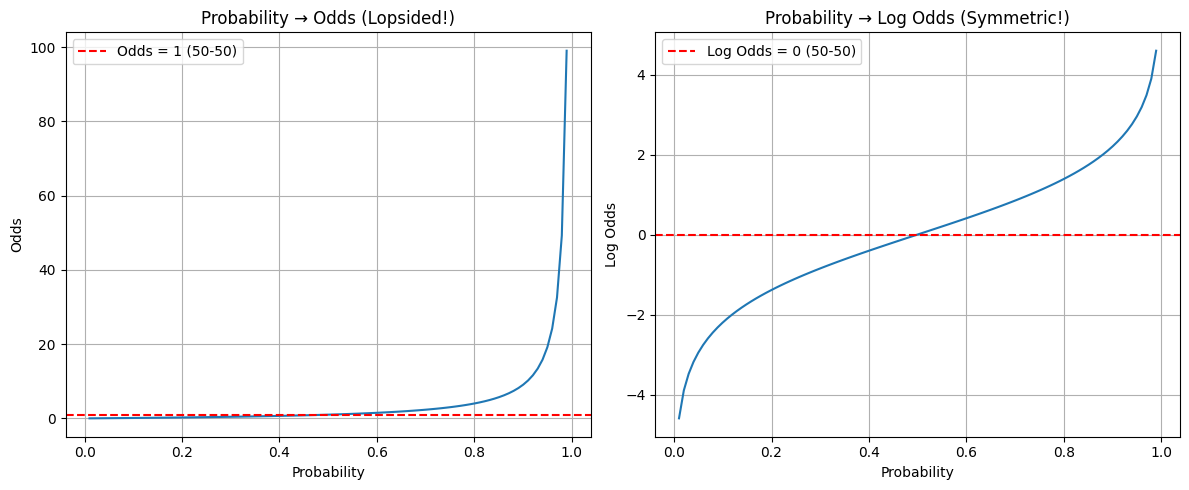

In [ ]:
# Visualization: Odds vs Log Odds
import torch
import matplotlib.pyplot as plt

p = torch.linspace(0.01, 0.99, 100)
odds = p / (1 - p)
log_odds = torch.log(odds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(p, odds)
axes[0].axhline(y=1, color='r', linestyle='--', label='Odds = 1 (50-50)')
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Odds')
axes[0].set_title('Probability → Odds (Lopsided!)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(p, log_odds)
axes[1].axhline(y=0, color='r', linestyle='--', label='Log Odds = 0 (50-50)')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Log Odds')
axes[1].set_title('Probability → Log Odds (Symmetric!)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Demonstrating: Same log odds change ≠ Same probability change
import torch

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

log_odds_A = torch.tensor(0.0)   # seesaw balanced
log_odds_B = torch.tensor(4.0)   # seesaw tilted high
added = 0.5

print("Before adding 0.5:")
print(f"  A: log odds = {log_odds_A.item()}, probability = {sigmoid(log_odds_A).item():.0%}")
print(f"  B: log odds = {log_odds_B.item()}, probability = {sigmoid(log_odds_B).item():.0%}")

print("\nAfter adding 0.5:")
print(f"  A: log odds = {(log_odds_A + added).item()}, probability = {sigmoid(log_odds_A + added).item():.0%}")
print(f"  B: log odds = {(log_odds_B + added).item()}, probability = {sigmoid(log_odds_B + added).item():.0%}")

print("\n→ Same +0.5 added, but A gained 12%, B gained only 1%!")

Before adding 0.5:
  A: log odds = 0.0, probability = 50%
  B: log odds = 4.0, probability = 98%

After adding 0.5:
  A: log odds = 0.5, probability = 62%
  B: log odds = 4.5, probability = 99%

→ Same +0.5 added, but A gained 12%, B gained only 1%!


---

## 5. Impact of Outliers

### 5.1 The Two Cases

| Case | Example | Loss | Impact |
|------|---------|------|--------|
| Outlier on correct side | Model confident & RIGHT | Small | Minimal |
| Outlier on wrong side | Model confident & WRONG | Huge! | Messes up training |

> **🎯 Analogy: The Cocky Weatherman**
>
> Weatherman says: "I'm 98% sure it will rain! Cancel your picnics!"
>
> It's bright sunshine. ☀️
>
> **The more confident you are when WRONG, the bigger the punishment!**

### 5.2 The Math: Why Confidence Explodes Loss

For a wrong prediction where true label = 0:

\[ \text{Loss} = -\log(1 - \hat{y}) \]

As \(\hat{y} \to 1\) (high confidence), \((1 - \hat{y}) \to 0\), and \(-\log(\text{tiny}) \to \infty\)

| Confidence (ŷ) | 1 - ŷ | Loss |
|----------------|-------|------|
| 50% | 0.5 | 0.69 |
| 90% | 0.1 | 2.3 |
| 98% | 0.02 | 3.9 |
| 99% | 0.01 | 4.6 |

### 5.3 The Chain Reaction

1. Confident but wrong → Big loss
2. Big loss → Big gradient
3. Big gradient → Model over-corrects
4. Over-correction → Ruins learning from thousands of normal cases

### 5.4 Practical Takeaway

**Find and remove outliers on the wrong side before training!**

---

## 6. Multiclass Classification

### 6.1 The Problem

Logistic regression is designed for yes/no questions. But what if we have 3+ classes?

> **🎯 Analogy: The Fruit Sorting Factory**
>
> Fruits come down a conveyor belt. You must sort into: 🍊 Orange, 🍎 Apple, 🍌 Banana
>
> How do we use a yes/no tool for a multiple choice question?

### 6.2 The Solution: One-vs-Rest (OVR)

Train **3 separate binary classifiers**:

| Detector | Question |
|----------|----------|
| Detector 1 | "Is it an Orange? Yes/No" |
| Detector 2 | "Is it an Apple? Yes/No" |
| Detector 3 | "Is it a Banana? Yes/No" |

### 6.3 How Labels Are Modified

Same data, different labels for each detector:

**Original:**
| Fruit | Label |
|-------|-------|
| 1 | Orange |
| 2 | Apple |
| 3 | Banana |

**For Orange Detector:**
| Fruit | Label |
|-------|-------|
| 1 | 1 |
| 2 | 0 |
| 3 | 0 |

**For Apple Detector:**
| Fruit | Label |
|-------|-------|
| 1 | 0 |
| 2 | 1 |
| 3 | 0 |

### 6.4 At Prediction Time

All detectors vote:
- Orange detector: 40%
- Apple detector: 35%
- Banana detector: 60%

**Pick highest → Banana!** 🍌

### 6.5 Why Probabilities Don't Sum to 100%

Each detector is a **separate model**. They don't know about each other!

40% + 35% + 60% = 135% — **Not a bug!**

### 6.6 sklearn Implementation

```python
model = LogisticRegression(multi_class='ovr')  # One-vs-Rest
model.fit(X_train, y_train)
```

---

## 7. Quiz Questions for Self-Assessment

### Quiz 1: Log Odds & Coefficients

**Question:** Two customers differ only in customer service calls:
- Customer A: 2 calls
- Customer B: 5 calls
- Coefficient for CustServ Calls: 0.8

Which is true?

a) Customer B's log odds is 2.4 higher than A's ✅

b) Customer B's probability is exactly 2.4 higher ❌

c) Customer B is guaranteed to churn ❌

**Explanation:**
- (a) ✅ Difference = 3 calls × 0.8 = 2.4 log odds
- (b) ❌ Same log odds change ≠ same probability change (Mountain Climber analogy!)
- (c) ❌ Higher log odds = more likely, never guaranteed. Sigmoid approaches but never reaches 1.

---

### Quiz 2: Outliers

**Question:** Model is 95% confident Customer X will NOT churn. Customer X churned. Impact?

a) Very little impact ❌

b) Huge impact ✅

c) Increase regularization to fix ❌

**Explanation:** Cocky Weatherman! Confident but wrong → Loss = \(-\log(0.05) = 3.0\) → Big gradient → Over-correction → Training messed up.

---

### Quiz 3: Multiclass Classification

**Question:** OVR outputs: Orange 40%, Apple 35%, Banana 60%

a) Which fruit? **Banana** (highest probability)

b) Why don't they sum to 100%? **Three separate models** — they don't know about each other!

---

## 8. Quick Reference

### Key Formulas

| Concept | Formula |
|---------|--------|
| Odds | \(\frac{p}{1-p}\) |
| Log Odds (Logit) | \(\log\left(\frac{p}{1-p}\right)\) |
| Sigmoid | \(\frac{1}{1+e^{-z}}\) |
| Accuracy | \(\frac{\text{correct}}{\text{total}}\) |
| Regularized Loss | \(\text{Error} + \lambda \times \text{Coefficients}\) |

### Sticky Analogies Summary

| Concept | Analogy |
|---------|--------|
| Regularization | Democracy for Features |
| Log Odds | Seesaw tilt |
| z computation | Weather Forecaster adding evidence |
| Same Δ log odds ≠ same Δ probability | Mountain Climber near summit |
| Outlier impact | Cocky Weatherman |
| Multiclass OVR | Fruit Sorting Factory |

### sklearn Cheat Sheet

```python
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)

# Binary Classification
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=0.001)  # C = 1/λ
model.fit(X_train, y_train)

# Multiclass Classification
model = LogisticRegression(multi_class='ovr')

# Inspect model
model.coef_       # Feature weights
model.intercept_  # Bias term
```

In [ ]:
#| hide

import subprocess
from pathlib import Path
from dialoghelper import curr_dialog

def deploy_notebook():
    nb_name = Path(curr_dialog()['name']).name + '.ipynb'
    src = f'/app/data/{curr_dialog()["name"]}.ipynb'
    dst = '/app/data/publish/portfolio/static/'
    print(nb_name)
    
    # Copy notebook to static folder
    subprocess.run(['cp', src, dst])
    
    # Deploy with plash
    subprocess.run(['plash_deploy'], cwd='/app/data/publish/portfolio')

In [ ]:
#| hide
deploy_notebook()